<a href="https://colab.research.google.com/github/fboldt/aulas-am-bsi/blob/main/aula7a_LogisticRegression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Carregar o dataset breast cancer.



In [1]:
from sklearn.datasets import load_breast_cancer

cancer = load_breast_cancer()

print(f"Dataset loaded with {cancer.data.shape[0]} samples and {cancer.data.shape[1]} features.")

Dataset loaded with 569 samples and 30 features.


In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(cancer.data, cancer.target, test_size=0.2, random_state=42)
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (455, 30)
X_test shape: (114, 30)


In [7]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit the scaler only on the training data and transform it
X_train_scaled = scaler.fit_transform(X_train)

# Transform the test data using the *same* fitted scaler
X_test_scaled = scaler.transform(X_test)

print("Data normalization complete.")
print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"X_test_scaled shape: {X_test_scaled.shape}")
print("First 5 rows of X_train_scaled:")
print(X_train_scaled[:5])

Data normalization complete.
X_train_scaled shape: (455, 30)
X_test_scaled shape: (114, 30)
First 5 rows of X_train_scaled:
[[-1.44075296 -0.43531947 -1.36208497 -1.1391179   0.78057331  0.71892128
   2.82313451 -0.11914956  1.09266219  2.45817261 -0.26380039 -0.01605246
  -0.47041357 -0.47476088  0.83836493  3.25102691  8.43893667  3.39198733
   2.62116574  2.06120787 -1.23286131 -0.47630949 -1.24792009 -0.97396758
   0.72289445  1.18673232  4.67282796  0.9320124   2.09724217  1.88645014]
 [ 1.97409619  1.73302577  2.09167167  1.85197292  1.319843    3.42627493
   2.01311199  2.66503199  2.1270036   1.55839569  0.80531919 -0.81268678
   0.75195659  0.87716951 -0.89605315  1.18122247  0.18362761  0.60059598
  -0.31771686  0.52963649  2.17331385  1.3112795   2.08161691  2.1374055
   0.76192793  3.26560084  1.92862053  2.6989469   1.89116053  2.49783848]
 [-1.39998202 -1.24962228 -1.34520926 -1.10978518 -1.33264483 -0.30735463
  -0.36555756 -0.69650228  1.93033305  0.95437877  0.02752055

## 3. Implementar um classificador linear utilizando descida de gradiente ou equação normal (pseudo-inversa). Faça uma implementação que aceite mais de 1 característica.

In [9]:
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.metrics import accuracy_score
import numpy as np

class LinearClassifier(BaseEstimator, ClassifierMixin):
    def __init__(self, learning_rate=0.01, num_iterations=1000):
        self.learning_rate = learning_rate
        self.num_iterations = num_iterations
        self.weights = None
        self.bias = None

    def fit(self, X, y):
        num_samples, num_features = X.shape
        self.weights = np.zeros(num_features)
        self.bias = 0
        for _ in range(self.num_iterations):
            y_predicted = self.predict(X)
            dw = (1 / num_samples) * np.dot(X.T, (y_predicted - y))
            db = (1 / num_samples) * np.sum(y_predicted - y)
            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db
        return self

    def predict(self, X):
        linear_model = np.dot(X, self.weights) + self.bias
        y_predicted = linear_model > 0
        return y_predicted.astype(int)

model = LinearClassifier()
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)


Accuracy: 0.9385964912280702


## 4. Plotar o MSE em função do valor de intercept e em função do valor do único coef.

In [ ]:
model = LinearClassifier()
model.fit(X_train_scaled, y_train)
print(model.bias, model.weights)

0.00026373626373627174 [-0.00079637]


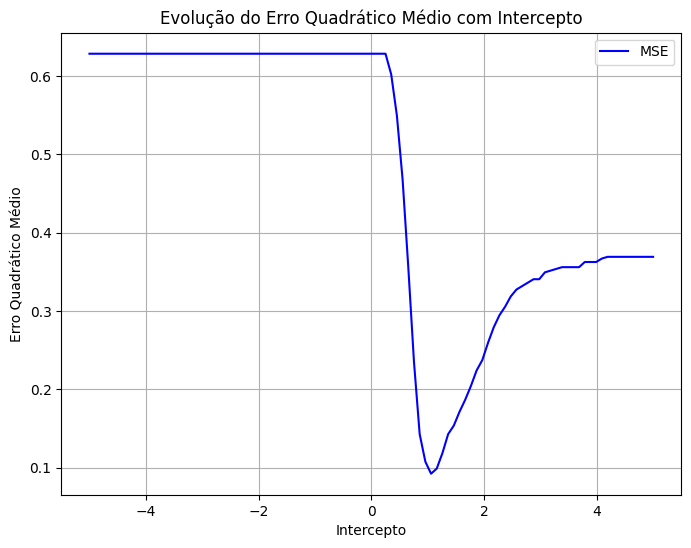

In [18]:
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

def plot_mse_by_intercept(model, X, y):
  intercept = model.bias
  offset = 5
  i_min = intercept - offset
  i_max = intercept + offset
  mse_list = []
  for i in np.linspace(i_min, i_max, 100):
    model.bias = i
    y_pred = model.predict(X)
    mse = mean_squared_error(y, y_pred)
    mse_list.append(mse)
  plt.figure(figsize=(8, 6))
  plt.plot(np.linspace(i_min, i_max, 100), mse_list
           , label="MSE", color="blue")
  model.bias = intercept
  plt.xlabel("Intercepto")
  plt.ylabel("Erro Quadrático Médio")
  plt.title("Evolução do Erro Quadrático Médio com Intercepto")
  plt.legend()
  plt.grid(True)
  plt.show()

plot_mse_by_intercept(model, X_train, y_train)

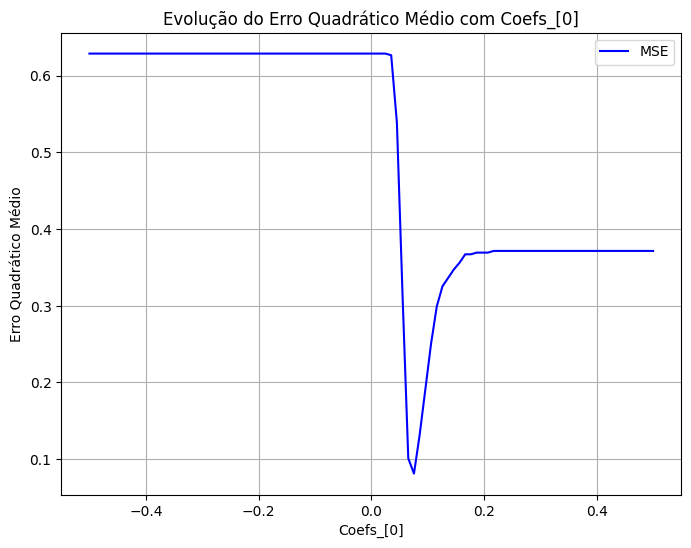

In [17]:
def plot_mse_by_coef0(model, X, y):
  coef0 = model.weights[0]
  offset = 0.5
  i_min = coef0 - offset
  i_max = coef0 + offset
  mse_list = []
  for i in np.linspace(i_min, i_max, 100):
    model.weights[0] = i
    y_pred = model.predict(X)
    mse = mean_squared_error(y, y_pred)
    mse_list.append(mse)
  plt.figure(figsize=(8, 6))
  plt.plot(np.linspace(i_min, i_max, 100), mse_list
           , label="MSE", color="blue")
  model.weights[0] = coef0
  plt.xlabel("Coefs_[0]")
  plt.ylabel("Erro Quadrático Médio")
  plt.title("Evolução do Erro Quadrático Médio com Coefs_[0]")
  plt.legend()
  plt.grid(True)
  plt.show()

plot_mse_by_coef0(model, X_train, y_train)

## 5. Comparar a performance da sua implementação com algum outro classificador linear do Scikit-Learn.

In [19]:
model = LinearClassifier()
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9385964912280702


In [ ]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))



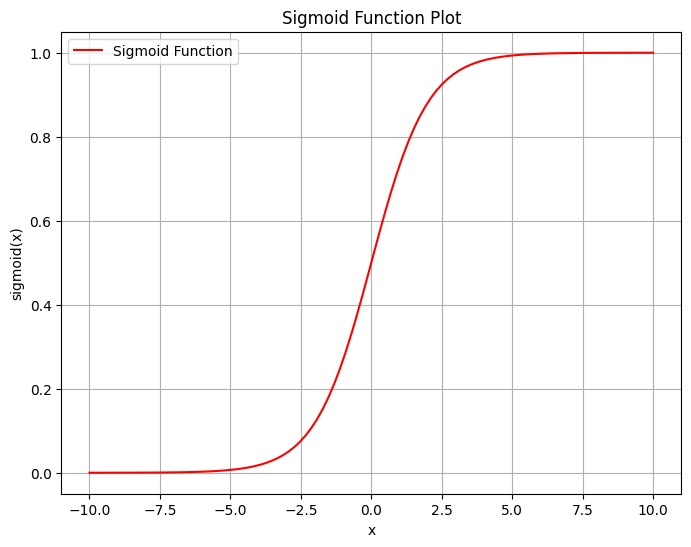

In [20]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

x = np.linspace(-10, 10, 100)
y = sigmoid(x)

plt.figure(figsize=(8, 6))
plt.plot(x, y, label='Sigmoid Function', color='red')
plt.title('Sigmoid Function Plot')
plt.xlabel('x')
plt.ylabel('sigmoid(x)')
plt.grid(True)
plt.legend()
plt.show()

In [25]:
class LogReg(BaseEstimator, ClassifierMixin):
    def __init__(self, learning_rate=0.01, num_iterations=1000):
        self.learning_rate = learning_rate
        self.num_iterations = num_iterations
        self.weights = None
        self.bias = None

    def fit(self, X, y):
        num_samples, num_features = X.shape
        self.weights = np.zeros(num_features)
        self.bias = 0
        for _ in range(self.num_iterations):
            # Calculate linear model output
            linear_model = np.dot(X, self.weights) + self.bias
            # Apply sigmoid function to get probabilities
            y_predicted_proba = sigmoid(linear_model)

            # Calculate gradients using probabilities
            dw = (1 / num_samples) * np.dot(X.T, (y_predicted_proba - y))
            db = (1 / num_samples) * np.sum(y_predicted_proba - y)

            # Update weights and bias
            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db
        return self

    def predict(self, X):
        linear_model = np.dot(X, self.weights) + self.bias
        y_predicted = sigmoid(linear_model) > 0.5 # Threshold at 0.5 for binary classification
        return y_predicted.astype(int)

model = LogReg()
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9824561403508771


In [26]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)


Accuracy: 0.9736842105263158
